# Regime-Sliced Performance for the §16.4 ETF Baseline

**Docker image**: `ml4t`

Section 16.6 argues that aggregate metrics can hide state-dependent fragility:
a strategy may earn its lifetime Sharpe in benign states and lose precisely when
investors most value diversification. This notebook implements the four-state
volatility × trend diagnostic on the §16.4 ETF momentum baseline, using
point-in-time regime labels and the actual backtest returns.

**Learning objectives**

1. Build point-in-time **volatility** and **trend** regime labels that respect
   the no-lookahead constraint.
2. Cross them into the four-state taxonomy from §16.6 (Risk-on / Caution /
   Crisis / Recovery) and compute regime-conditional Sharpe, CAGR, vol, MDD.
3. Read the **regime-conditional drawdown** profile and explain why
   observation count tempers strong claims about thin states.

**Book reference**: Chapter 16, §16.6 (Diagnosing the Economic Value).
**Prerequisites**: §16.4 baseline (NB01); the helper `_etf_baseline.py`
reproduces its returns and weights.

In [1]:
"""§16.6 regime-sliced performance on the §16.4 ETF momentum baseline."""

import numpy as np
import pandas as pd
from _etf_baseline import (
    load_panel,
    metrics,
    momentum_weights,
    simulate,
)

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
VOL_LOOKBACK = 60  # trading days for realized volatility window
TREND_LOOKBACK = 126  # ~6 months for the trend signal (cumulative return)
INDEX_SYMBOL = "SPY"  # market index used to define vol/trend regimes

## 1. Run the §16.4 ETF Baseline

We reuse the §16.4 momentum strategy: top-3 risk-adjusted-momentum ETFs in
risk-on regimes, 60% AGG / 40% TLT in risk-off, monthly rebalance, 5 bp per
leg. The helper module exposes the same simulator NB01 uses, so the equity
series here matches Table 16.4 exactly.

In [3]:
panel = load_panel(START_DATE, END_DATE)
weights = momentum_weights(panel)
result = simulate(panel.prices, weights)

baseline_metrics = metrics(result.equity)
print(
    f"§16.4 baseline (Table 16.4): "
    f"CAGR={baseline_metrics['cagr'] * 100:.2f}%  "
    f"Sharpe={baseline_metrics['sharpe']:.2f}  "
    f"MaxDD={baseline_metrics['max_drawdown'] * 100:.1f}%"
)

§16.4 baseline (Table 16.4): CAGR=7.41%  Sharpe=0.65  MaxDD=-31.9%


## 2. Point-in-Time Volatility Regime

Following §16.6, define

$$\sigma_t = \text{trailing 60-day realized volatility of the market index}$$

and an **expanding median** $m_t$ of $\{\sigma_s : s < t\}$. The expanding
median is point-in-time: it never uses future observations. The volatility
state is `Low` when $\sigma_t < m_t$, `High` otherwise.

In [4]:
spy_returns = panel.prices[INDEX_SYMBOL].pct_change()
realized_vol = spy_returns.rolling(VOL_LOOKBACK).std() * np.sqrt(252)
expanding_median_vol = realized_vol.expanding().median().shift(1)  # strictly past

# Both labels use only past information: realized_vol.shift(1) excludes the
# current bar so day-t's regime depends on data through t-1, matching the
# trend label and the prose claim in §2.
vol_state = pd.Series(
    np.where(realized_vol.shift(1) < expanding_median_vol, "Low", "High"),
    index=panel.prices.index,
    name="vol_state",
)
vol_state[realized_vol.shift(1).isna() | expanding_median_vol.isna()] = "Warmup"

## 3. Point-in-Time Trend Regime

Define the trend signal as the trailing 6-month total return of the market
index, $\rho_t = P_t / P_{t-126} - 1$. The trend state is `Up` when
$\rho_t$ is above its expanding median $\tilde\rho_t = \text{median}\{
\rho_s : s < t \}$ and `Down` otherwise. The threshold is point-in-time
(no future observations enter $\tilde\rho_t$) and the marginal trend split
is 50/50 by construction (median-based). The *joint* distribution after
crossing with the volatility state remains sample-dependent — the realized
four-state cell counts on this sample are Risk-on 36%, Crisis 34%, Recovery
17%, Caution 13%.

In [5]:
trend_signal = panel.prices[INDEX_SYMBOL].pct_change(TREND_LOOKBACK)
expanding_median_trend = trend_signal.expanding().median().shift(1)  # strictly past

trend_state = pd.Series(
    np.where(trend_signal.shift(1) > expanding_median_trend, "Up", "Down"),
    index=panel.prices.index,
    name="trend_state",
)
trend_state[trend_signal.shift(1).isna() | expanding_median_trend.isna()] = "Warmup"

## 4. The Four-State Cross

Cross volatility × trend to recover the §16.6 taxonomy.
The lagged labels are aligned with the day-$t$ strategy return so that no
future information enters the regime classification.

In [6]:
def four_state(vol: str, trend: str) -> str:
    if vol == "Warmup" or trend == "Warmup":
        return "Warmup"
    return {
        ("Low", "Up"): "Risk-on",
        ("High", "Up"): "Caution",
        ("High", "Down"): "Crisis",
        ("Low", "Down"): "Recovery",
    }[(vol, trend)]


regime = pd.Series(
    [four_state(v, t) for v, t in zip(vol_state, trend_state, strict=True)],
    index=panel.prices.index,
    name="regime",
)

Distribution of the four states across the sample (warm-up days excluded
from the diagnostic):

In [7]:
regime.value_counts().rename("days").to_frame()

,days
regime,
Risk-on,1223
Crisis,1146
Recovery,572
Caution,454
Warmup,127


## 5. Regime-Conditional Performance

For each state, recompute the same metric family used in the tear sheet
(§16.5). Sample sizes vary substantially across states, so we report the
observation count alongside Sharpe — thin states deserve more skepticism
than thick ones.

In [8]:
returns = result.returns
regime_aligned = regime.reindex(returns.index)

rows = []
total_days = (regime_aligned != "Warmup").sum()
for state in ["Risk-on", "Caution", "Crisis", "Recovery"]:
    mask = regime_aligned == state
    n = int(mask.sum())
    if n < 20:
        rows.append(
            {
                "regime": state,
                "days": n,
                "pct_time": n / total_days if total_days else np.nan,
                "cagr": np.nan,
                "vol": np.nan,
                "sharpe": np.nan,
                "max_dd": np.nan,
            }
        )
        continue
    r = returns[mask]
    cagr = float((1 + r.mean()) ** 252 - 1)
    vol = float(r.std() * np.sqrt(252))
    sharpe = cagr / vol if vol > 0 else 0.0
    cum = (1 + r).cumprod()
    rmax = cum.expanding().max()
    mdd = float(((cum - rmax) / rmax).min())
    rows.append(
        {
            "regime": state,
            "days": n,
            "pct_time": n / total_days,
            "cagr": cagr,
            "vol": vol,
            "sharpe": sharpe,
            "max_dd": mdd,
        }
    )

# Append overall row using the same active-sample window (excluding warm-up)
mask_all = regime_aligned.isin(["Risk-on", "Caution", "Crisis", "Recovery"])
r_all = returns[mask_all]
cagr_all = float((1 + r_all.mean()) ** 252 - 1)
vol_all = float(r_all.std() * np.sqrt(252))
cum_all = (1 + r_all).cumprod()
rmax_all = cum_all.expanding().max()
mdd_all = float(((cum_all - rmax_all) / rmax_all).min())
rows.append(
    {
        "regime": "Overall",
        "days": int(mask_all.sum()),
        "pct_time": 1.0,
        "cagr": cagr_all,
        "vol": vol_all,
        "sharpe": cagr_all / vol_all if vol_all > 0 else 0.0,
        "max_dd": mdd_all,
    }
)

regime_table = pd.DataFrame(rows)
regime_table

,regime,days,pct_time,cagr,vol,sharpe,max_dd
0,Risk-on,1223,0.360236,0.015740,0.106881,0.147268,-0.183333
1,Caution,454,0.133726,0.170957,0.139548,1.225081,-0.138556
2,Crisis,1146,0.337555,0.066168,0.119368,0.554320,-0.240079
3,Recovery,572,0.168483,0.164323,0.098908,1.661365,-0.108493
4,Overall,3395,1.000000,0.076804,0.114795,0.669059,-0.318598


**Reading the table.** The §16.6 prose claim — that aggregate metrics can mask
state dependence — is concrete here:

- **Risk-on** (Low vol + Up trend) has the largest observation count (36%
  of active days) but the *lowest* conditional Sharpe (0.15). The strategy
  under-earns precisely when buy-and-hold dominates: the curve filter holds
  the top three momentum ETFs equally weighted, so a single SPY-led rally
  shows up at a much lower risk-adjusted return than the benchmark would.
- **Recovery** (Low vol + Down trend) carries the *highest* conditional
  Sharpe (1.66) — low-volatility windows that follow sustained drawdowns
  combine modest realized return with a small denominator and post-decline
  mean reversion.
- **Caution** (High vol + Up trend) is second strongest (1.23): the §16.4
  defensive AGG/TLT sleeve profits in high-vol periods where the curve
  filter has already rotated out of equities. Caution is also the thinnest
  cell (13% of active days, 454 observations) — a sample-size caveat applies.
- **Crisis** (High vol + Down trend) carries the deepest within-regime
  drawdown (−24.0%). The binary curve filter rotates to bonds only once the
  signal flips, leaving residual equity exposure to fast crises.
- The **Overall** Sharpe (0.65) sits between Crisis (0.55) and Recovery
  (1.66). Aggregate performance reflects the regime mix, not regime-invariant
  skill: most of the lifetime risk-adjusted return is earned in Caution and
  Recovery, the two thinnest cells.

## 6. Tail Risk per Regime — `ml4t-diagnostic`

§16.6 cares about *when* losses arrive, not just how often. The conditional
Sharpe table above answers "what is the average risk-adjusted return in
each state?". The tail-risk view answers "in each state, how bad is a bad
day?". `plot_tail_risk_analysis` from `ml4t.diagnostic.visualization.backtest`
renders the empirical return distribution with VaR / CVaR markers — at
95% and 99% confidence by default — alongside the headline statistics.

We render the diagnostic for the **overall** sample and for the **Crisis**
state separately. The Crisis cut is the one §16.6 highlights as the most
investor-relevant: a strategy with a tolerable aggregate CVaR but a much
deeper Crisis-state CVaR is fragile in exactly the moments that matter.

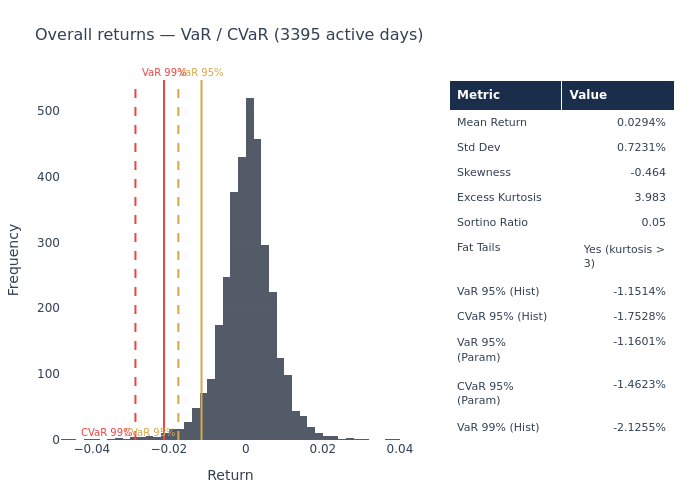

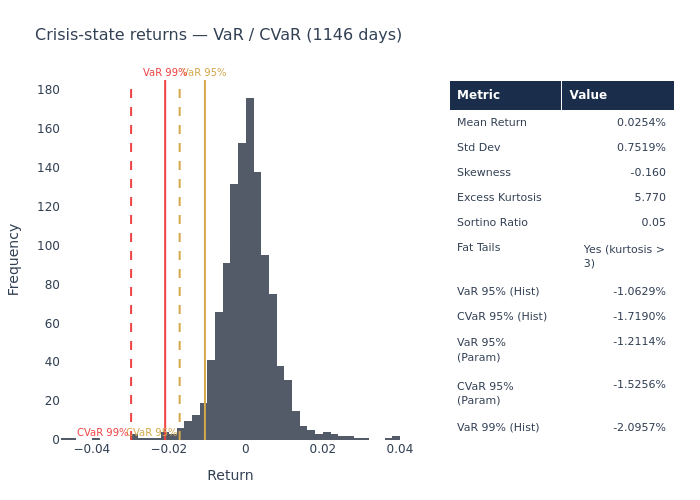

In [9]:
from ml4t.diagnostic.visualization.backtest.tail_risk import plot_tail_risk_analysis

overall_returns = returns[mask_all].to_numpy()
fig_overall = plot_tail_risk_analysis(
    overall_returns,
    title=f"Overall returns — VaR / CVaR ({mask_all.sum()} active days)",
)
fig_overall.show()

crisis_mask = regime_aligned == "Crisis"
crisis_returns = returns[crisis_mask].to_numpy()
if crisis_returns.size >= 20:
    fig_crisis = plot_tail_risk_analysis(
        crisis_returns,
        title=f"Crisis-state returns — VaR / CVaR ({crisis_returns.size} days)",
    )
    fig_crisis.show()
else:
    print(f"Crisis state has only {crisis_returns.size} days — skipping (under threshold).")

Read the two figures together: the gap between the overall CVaR and the
Crisis-state CVaR is the §16.6 fragility wedge. A strategy with a small
wedge tolerates regime shifts; a strategy with a wide wedge is delivering
its lifetime metrics by avoiding the conditions that hurt it most.

## 7. Regime-Sliced Drawdown

A regime can absorb mean-return weakness through diversification while still
producing a deep conditional drawdown. The drawdown attribution below
decomposes the largest full-sample drawdown into its regime-specific
components.

In [10]:
cum = result.equity / result.equity.iloc[0]
running_max = cum.expanding().max()
drawdown = (cum - running_max) / running_max
trough_date = drawdown.idxmin()
peak_date = cum.loc[:trough_date].idxmax()

mask_dd = (cum.index >= peak_date) & (cum.index <= trough_date)
dd_returns = returns[mask_dd[1:]]  # drop first index (no return)
dd_regime = regime_aligned.loc[dd_returns.index]
attribution = dd_returns.groupby(dd_regime).agg(["count", "mean", "sum"]).rename_axis("regime")
attribution.columns = ["days", "mean_daily_return", "cumulative_return"]
print(
    f"Largest drawdown: peak {peak_date.date()} → trough {trough_date.date()} "
    f"({drawdown.min() * 100:.1f}%, {(trough_date - peak_date).days} days)"
)
attribution

Largest drawdown: peak 2021-11-18 → trough 2023-10-19 (-31.9%, 700 days)


,days,mean_daily_return,cumulative_return
regime,,,
Caution,68,-0.000785,-0.053362
Crisis,316,-0.000533,-0.168402
Recovery,14,-0.001347,-0.018854
Risk-on,84,-0.001451,-0.121921


Each row reports the cumulative return contribution of days assigned to that
regime *during the worst drawdown episode*. This is the §16.6 "drawdown
attribution" diagnostic: it explains which states were responsible for the
loss path. Recovery happens when the strategy re-enters Risk-on; the
attribution clarifies whether the drawdown originated in expected
(Crisis-state) losses or in unexpected weakness in supposedly favorable
states.

## Key Takeaways

1. **Point-in-time labels are non-negotiable.** The expanding median and the
   trailing-return trend signal both shift by one bar so the regime at time
   $t$ classifies returns realized at $t$ using only information visible by
   $t-1$. A full-sample median or an unshifted trend signal would contaminate
   the diagnostic with future information.
2. **The four-state taxonomy is transparent and auditable.** Two thresholds,
   no latent states, no tuning. §16.6 calls this a feature, not a limitation:
   diagnostic regimes should be hard to overfit.
3. **Sample size tempers state-level claims.** Caution is the thinnest cell
   (454 active days, 13% of the sample); Recovery is second-thinnest (572,
   17%). The two cells with the strongest conditional Sharpes are also the
   cells where the estimate is least precise. Observation count belongs in
   the regime table for the same reason confidence intervals belong in §16.7's
   Sharpe inference: point estimates on thin samples are not precise
   predictions of future state-conditional behavior.
4. **Drawdown attribution closes the regime story.** A favorable aggregate
   Sharpe with a deep Crisis-state drawdown still leaves an investor exposed
   when capital is most valuable. §16.6 calls this the bridge between
   statistical performance and investor utility.

**What is NOT in this notebook**: regime-specific stationarity tests, ARCH
modeling, walk-forward fold-by-fold regime mismatch. Those belong with
Chapter 9 feature stationarity (test discipline) and Chapter 7 evaluation
protocol, not with §16.6's economic-value diagnostic.